# Task 1: Basics - loading data, visualization, segmentation, filtering

## 1.1 Loading data and filtering it

The processing order for optical motion capture data is usually as follows:
1. Record OMC data (marker trajectories) + force plate data (ground reaction forces)
2. Label markers and fill gaps in the marker trajectories (already done for you)
3. Scale musculoskeletal model to the subject (more info [here](https://opensimconfluence.atlassian.net/wiki/spaces/OpenSim/pages/53089741/Tutorial+3+-+Scaling+Inverse+Kinematics+and+Inverse+Dynamics))
4. Inverse kinematics: calculate joint angles from marker trajectories
5. Filter marker trajectories and joint angles -- to remove high-frequency noise. Always filter whole trajectories, not only segments ()
6. Inverse dynamics: calculate joint moments from joint angles and ground reaction forces

**To Do:**

Go to filter.py and implement a 4th zero-lag Butterworth low-pass filter with a cutoff frequency of 6 Hz. You can use the scipy functions `scipy.signal.butter` and `scipy.signal.filtfilt` for this.

Then run the next cell to visualize the effect of filtering on the marker trajectories. You should see that high-frequency noise is removed, but the overall shape of the signal is preserved.

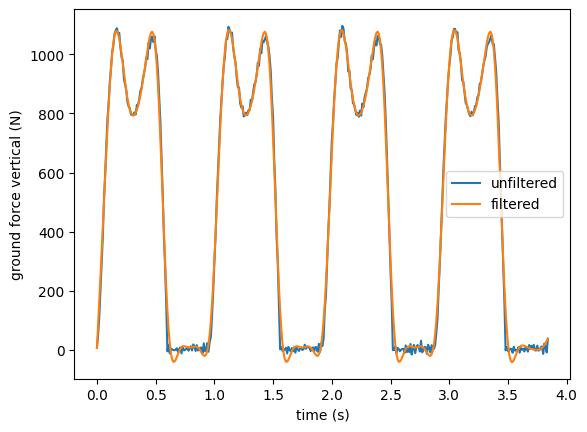

In [1]:
from utils import filter
import matplotlib.pyplot as plt
import pandas as pd

grf_data = pd.read_csv('data/grf.csv')
# This filter needs to be implemented by you in utils/filter.py first!
filtered_grf_data = filter.butterworth_lowpass_filter(grf_data, cutoff=6, fs=100, order=4)
plt.plot(grf_data['time'], grf_data['force_r_y'], label='unfiltered')
plt.plot(filtered_grf_data['time'], filtered_grf_data['force_r_y'], label='filtered')
plt.xlabel('time (s)')
plt.ylabel('ground force vertical (N)')
plt.legend()

Run `pytest tests.py` to check if the first part of your implementation is correct - 2 tests should pass now.

## 1.2 Segmenting gait cycles
We can use the vertical ground reaction force (GRF) to identify heel strikes and toe offs. A common threshold is 20 N: if the vertical GRF exceeds this value, the foot is on the ground. Always use the unfiltered GRF data for this.

Next cell plots the points we roughly search for:

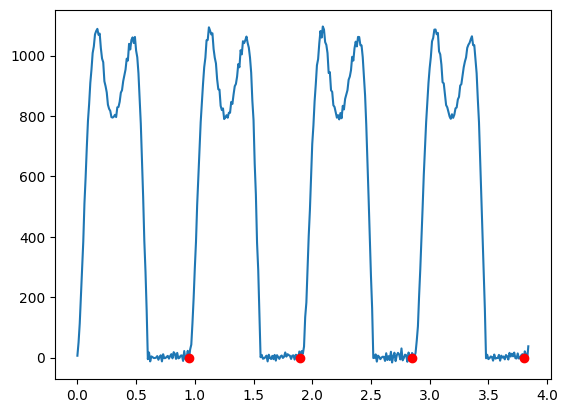

In [2]:
plt.plot(grf_data['time'], grf_data['force_r_y'], label='unfiltered')
plt.plot(0.95, 0, 'ro')  # heel strike 1
plt.plot(0.95*2, 0, 'ro')  # heel strike 2
plt.plot(0.95*3, 0, 'ro')  # heel strike 2
plt.plot(0.95*4, 0, 'ro')  # heel strike 2


**To Do:**

Now, implement the function `segment_gait_cycles` in `utils/segment.py` that segments the data into individual gait cycles based on heel strikes. Use a threshold of 60 N on the unfiltered vertical ground reaction force to identify heel strikes. The function should also clean the data: remove gait cycles that do not reach a minimum force of 300 N (to remove partial steps, noise outliers, etc.). Then, remove all gait cycles that are +- 2 standard deviations away from the mean gait cycle duration (to remove outliers). The function should return a list of data frames, each containing one gait cycle. 

Then execute the next cell to see all gait cycles overlaid. Do you see a clear pattern as in the lecture slides?

Number of gait cycles remaining: 3


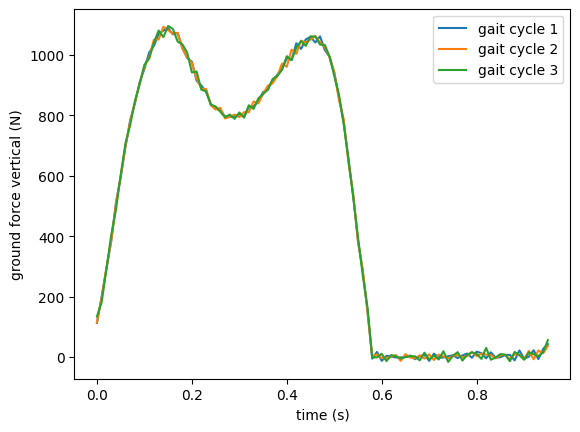

In [3]:
from utils import segment
gait_cycles = segment.segment_gait_cycles(grf_data.force_r_y, data=grf_data, threshold=60)
for i, cycle in enumerate(gait_cycles):
    plt.plot(cycle['time'], cycle['force_r_y'], label=f'gait cycle {i+1}')
plt.xlabel('time (s)')
plt.ylabel('ground force vertical (N)')
plt.legend()
print(f'Number of gait cycles remaining: {len(gait_cycles)}')

## 1.3 Ensemble averaging gait cycles

**To Do:**

Implement a function `ensemble_average` in `utils/segment.py` that takes a list of data frames (gait cycles) and returns the ensemble average and standard deviation. The function should first resample each gait cycle to 100 data points (using linear interpolation), then calculate the mean and standard deviation across all cycles.

Then execute the next cell to visualize the ensemble average and standard deviation of the vertical ground reaction force across all gait cycles. You should see a smooth curve representing the average GRF pattern during walking, with shaded areas indicating variability across cycles.

This should look like the plots in the lecture slides.

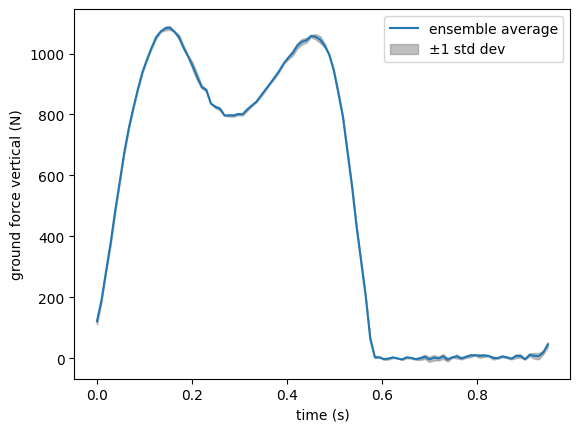

In [4]:
ensemble_average, ensemble_std = segment.ensemble_average(gait_cycles)
plt.plot(ensemble_average['time'], ensemble_average['force_r_y'], label='ensemble average')
plt.fill_between(ensemble_average['time'], 
                 ensemble_average['force_r_y'] - ensemble_std['force_r_y'],
                 ensemble_average['force_r_y'] + ensemble_std['force_r_y'],
                 color='gray', alpha=0.5, label='±1 std dev')
plt.xlabel('time (s)')
plt.ylabel('ground force vertical (N)')
plt.legend()

If that all worked, check out the test function again: `pytest tests.py` - 1 more test should pass now!

## 1.4 To do: Visualize joint angles

In [5]:
print(ensemble_average.columns)

Index(['time', 'force_r_x', 'force_r_y', 'cop_r_x', 'force_l_x', 'force_l_y',
       'cop_l_x'],
      dtype='object')


**To Do:**

Visualize the following ensemble averages with standard deviations (plots similar to the lecture slides):
- Hip flexion/extension
- Knee flexion/extension
- Ankle dorsiflexion/plantarflexion
- Ground reaction force (horizontal and vertical)
Make it look nice (labels, legends, etc.) and compare to the plots in the lecture slides. Do they look similar? (Hint: our data is very clean, so the plots should look very similar to the lecture slides - if not, check your code again!)

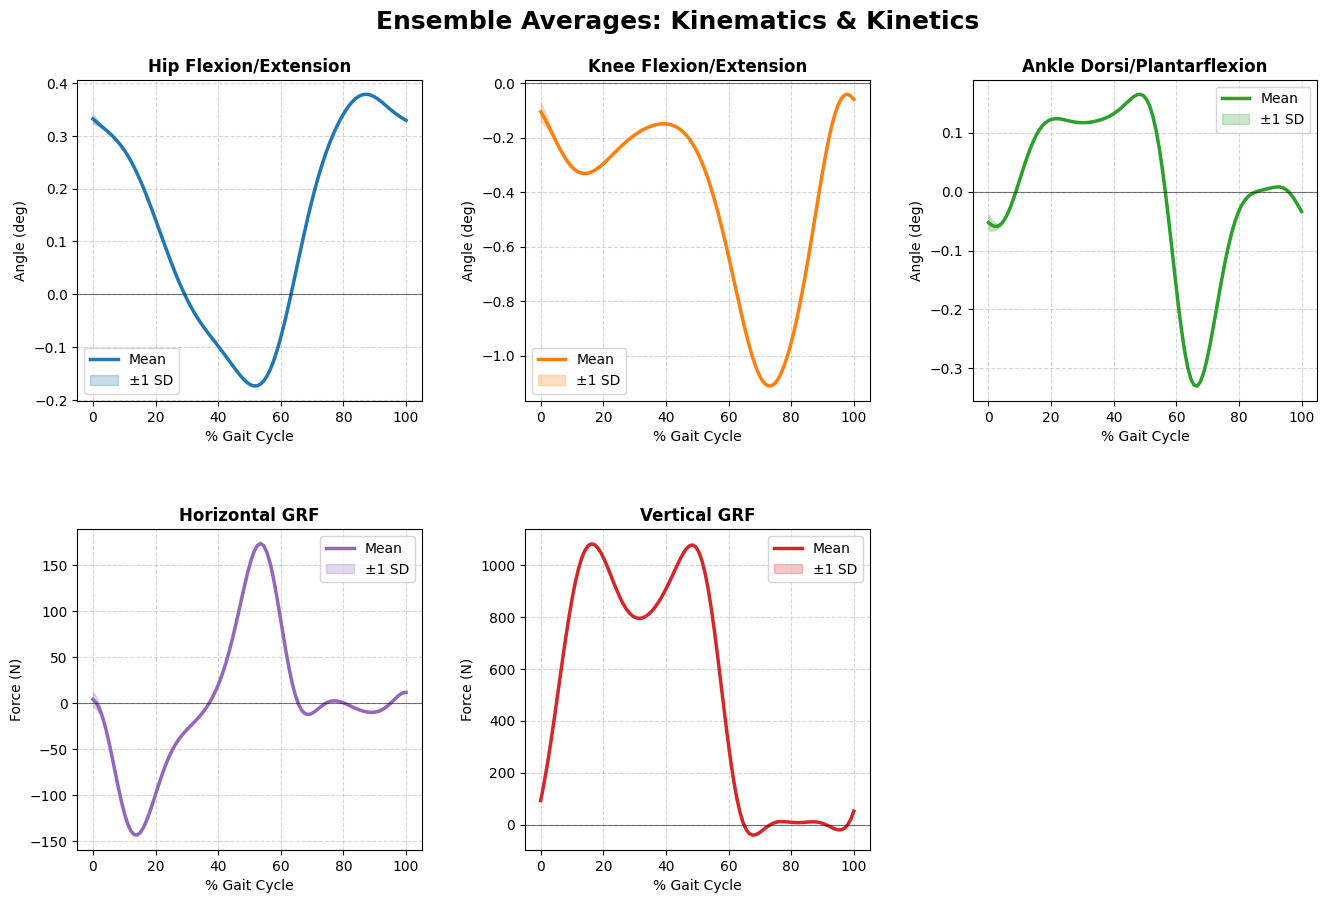

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import segment, filter

# --- 1. PREPARE THE MISSING DATA ---
# Load and filter the angles (since 1.2 didn't do it)
angles_data = pd.read_csv('data/angles.csv')
filtered_angles = filter.butterworth_lowpass_filter(angles_data, cutoff=6, fs=100, order=4)

# We can safely use 'grf_data' from cell 1.1! Let's filter it again just to be safe.
filtered_grf = filter.butterworth_lowpass_filter(grf_data, cutoff=6, fs=100, order=4)

# Combine forces and angles into one big table
combined_data = pd.concat([filtered_grf, filtered_angles.drop(columns=['time'])], axis=1)

# Segment and average this new combined table
combined_cycles = segment.segment_gait_cycles(combined_data['force_r_y'], data=combined_data, threshold=60)
mean_data, std_data = segment.ensemble_average(combined_cycles)


# --- 2. PLOT THE DATA ---
percent_gait = np.linspace(0, 100, 100) # X-axis is 0 to 100%

# Set up a 2x3 grid for our 5 plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

# The 5 variables your professor asked for
variables_to_plot = [
    {'col': 'hip_flexion_r', 'title': 'Hip Flexion/Extension', 'ylabel': 'Angle (deg)', 'color': 'tab:blue'},
    {'col': 'knee_angle_r', 'title': 'Knee Flexion/Extension', 'ylabel': 'Angle (deg)', 'color': 'tab:orange'},
    {'col': 'ankle_angle_r', 'title': 'Ankle Dorsi/Plantarflexion', 'ylabel': 'Angle (deg)', 'color': 'tab:green'},
    {'col': 'force_r_x', 'title': 'Horizontal GRF', 'ylabel': 'Force (N)', 'color': 'tab:purple'},
    {'col': 'force_r_y', 'title': 'Vertical GRF', 'ylabel': 'Force (N)', 'color': 'tab:red'}
]

for i, var in enumerate(variables_to_plot):
    ax = axes[i]
    col = var['col']
    
    # Check if the column exists to prevent crashing
    if col in mean_data.columns:
        mean = mean_data[col]
        std = std_data[col]
        
        # Plot mean and shaded standard deviation
        ax.plot(percent_gait, mean, color=var['color'], linewidth=2.5, label='Mean')
        ax.fill_between(percent_gait, mean - std, mean + std, color=var['color'], alpha=0.25, label='±1 SD')
        
        # Formatting
        ax.set_title(var['title'], fontweight='bold')
        ax.set_xlabel('% Gait Cycle')
        ax.set_ylabel(var['ylabel'])
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()
    else:
        ax.text(0.5, 0.5, f"Column '{col}' missing.", ha='center', va='center', color='red', weight='bold')

# Remove the 6th empty subplot
fig.delaxes(axes[5])

plt.suptitle('Ensemble Averages: Kinematics & Kinetics', fontsize=18, fontweight='bold', y=0.95)
plt.show()

Tests running? Plots done? Great! You are done with assignment 1. 